In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels
import streamlit
import plotly

print("Everything is working!")

Everything is working!


In [5]:
import pandas as pd

df = pd.read_csv("data/insurance.csv")

df.head()
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape of dataset: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows:
1


In [30]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Select numerical columns
numerical_cols = ['age', 'bmi', 'children', 'charges']

# Create descriptive statistics table
descriptive_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Standard Deviation': df[numerical_cols].std(),
    'IQR': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurtosis()
})

descriptive_stats

,Mean,Median,Standard Deviation,IQR,Skewness,Kurtosis
age,39.207025,39.000,14.049960,24.000000,0.055673,-1.245088
bmi,30.663397,30.400,6.098187,8.397500,0.284047,-0.050732
children,1.094918,1.000,1.205493,2.000000,0.938380,0.202454
charges,13270.422265,9382.033,12110.011237,11899.625365,1.515880,1.606299


In [8]:
descriptive_stats.round(2)

,Mean,Median,Standard Deviation,IQR,Skewness,Kurtosis
age,39.21,39.00,14.05,24.00,0.06,-1.25
bmi,30.66,30.40,6.10,8.40,0.28,-0.05
children,1.09,1.00,1.21,2.00,0.94,0.20
charges,13270.42,9382.03,12110.01,11899.63,1.52,1.61


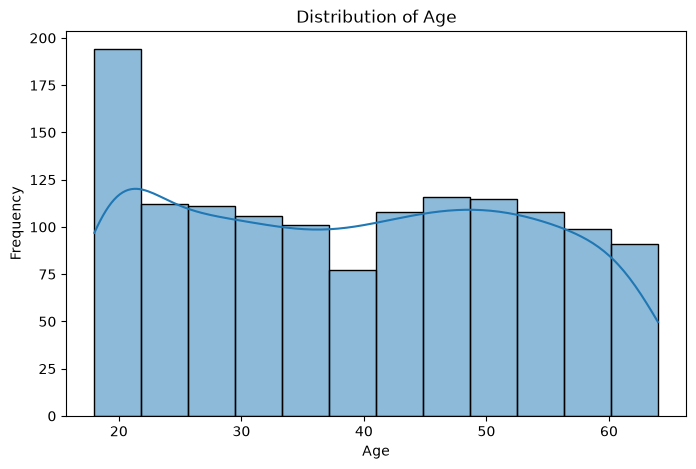

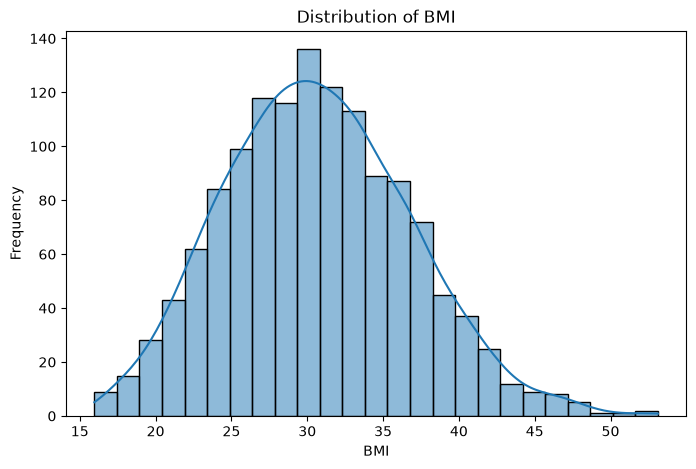

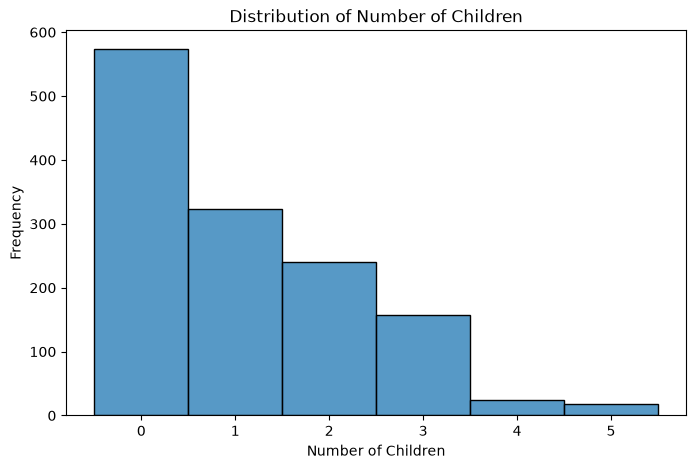

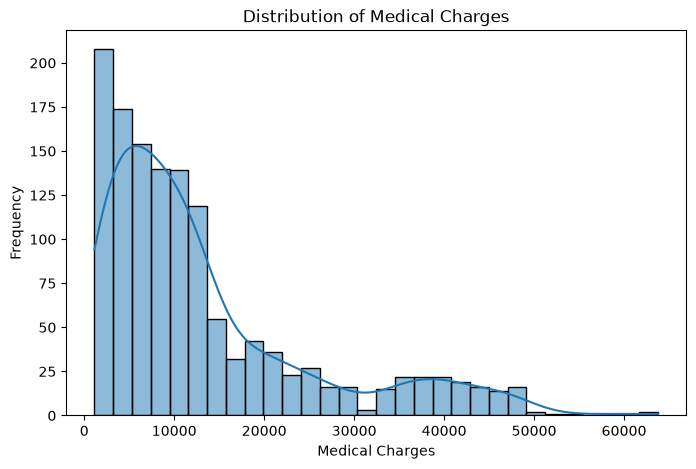

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df['age'], kde=True)

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(df['bmi'], kde=True)

plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(df['children'], kde=False, discrete=True)

plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Frequency')

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(df['charges'], kde=True)

plt.title('Distribution of Medical Charges')
plt.xlabel('Medical Charges')
plt.ylabel('Frequency')

plt.show()

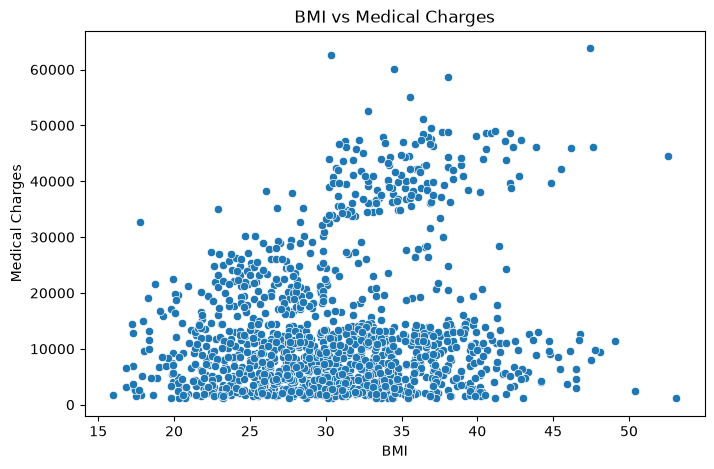

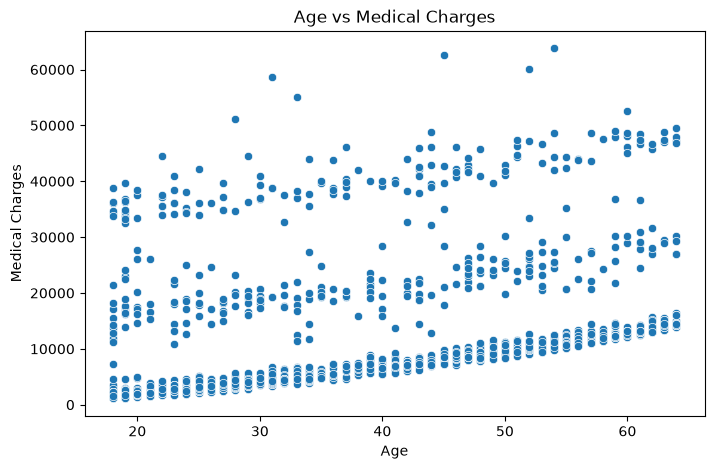

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='bmi', y='charges')

plt.title('BMI vs Medical Charges')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')

plt.show()

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='age', y='charges')

plt.title('Age vs Medical Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')

plt.show()

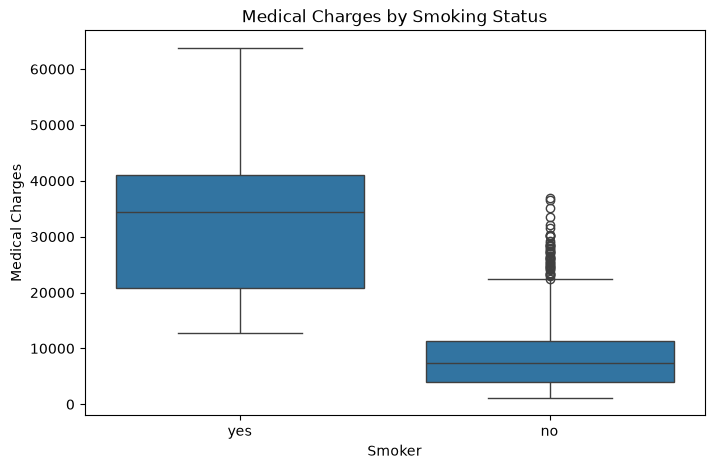

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='smoker', y='charges')

plt.title('Medical Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Medical Charges')

plt.show()

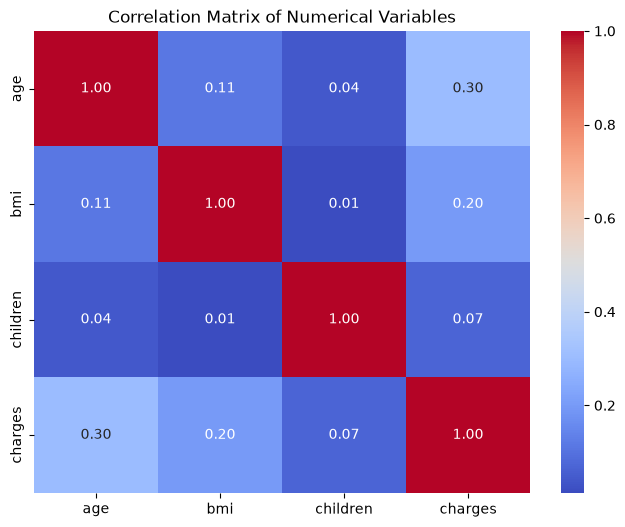

In [16]:
correlation_matrix = df[['age', 'bmi', 'children', 'charges']].corr()

correlation_matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [ ]:


df.groupby('smoker')['charges'].agg(['count', 'mean', 'median', 'std'])

Number of smokers: 274
Number of non-smokers: 1064


,count,mean,median,std
smoker,,,,
no,1064,8434.268298,7345.40530,5993.781819
yes,274,32050.231832,34456.34845,11541.547176


In [26]:
from scipy.stats import shapiro

smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

stat_smoker, p_smoker = shapiro(smokers)
stat_non_smoker, p_non_smoker = shapiro(non_smokers)

print("Shapiro-Wilk Test")
print("------------------")

print("Smokers:")
print("Test statistic =", stat_smoker)
print("p-value =", p_smoker)

print("\nNon-smokers:")
print("Test statistic =", stat_non_smoker)
print("p-value =", p_non_smoker)

Shapiro-Wilk Test
------------------
Smokers:
Test statistic = 0.9395519382929163
p-value = 3.624989722535372e-09

Non-smokers:
Test statistic = 0.8728637657660203
p-value = 1.4459006863640269e-28


In [21]:
from scipy.stats import levene

stat_levene, p_levene = levene(smokers, non_smokers)

print("Levene statistic:", stat_levene)
print("Levene p-value:", p_levene)
if p_levene > 0.05:
    print("Variances are equal.")
else:
    print("Variances are not equal.")

Levene statistic: 332.6135162726081
Levene p-value: 1.5593284881791394e-66
Variances are not equal.


In [22]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    smokers,
    non_smokers,
    alternative='two-sided'
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

alpha = 0.05

if p < alpha:
    print("Reject H0")
    print("There is a significant difference in medical charges between smokers and non-smokers.")
else:
    print("Fail to reject H0")
    print("There is no significant difference in medical charges between smokers and non-smokers.")

Mann-Whitney U statistic: 284133.0
p-value: 5.270233444503571e-130
Reject H0
There is a significant difference in medical charges between smokers and non-smokers.


In [24]:
from scipy.stats import f_oneway

northwest = df[df['region'] == 'northwest']['charges']
northeast = df[df['region'] == 'northeast']['charges']
southwest = df[df['region'] == 'southwest']['charges']
southeast = df[df['region'] == 'southeast']['charges']

anova_stat, anova_p = f_oneway(
    northwest,
    northeast,
    southwest,
    southeast
)

print("F-statistic:", anova_stat)
print("p-value:", anova_p)
alpha = 0.05

if anova_p < alpha:
    print("Reject H0")
    print("Medical charges differ significantly across regions.")
else:
    print("Fail to reject H0")
    print("There is no significant difference in medical charges across regions.")

print(df.groupby('region')['charges'].mean())
print(df.groupby('region')['charges'].median())    

F-statistic: 2.9696266935891193
p-value: 0.03089335607049739
Reject H0
Medical charges differ significantly across regions.
region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64
region
northeast    10057.652025
northwest     8965.795750
southeast     9294.131950
southwest     8798.593000
Name: charges, dtype: float64


In [27]:
# Convert categorical variables into dummy variables

df_model = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

df_model.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [32]:
import statsmodels.api as sm

# Dependent variable (Y)
y = df_model['charges']

# Independent variables (X)
X = df_model.drop('charges', axis=1)

# Add intercept (constant) to the model
X = sm.add_constant(X)

print("X shape:", X.shape)
print("Y shape:", y.shape)

model = sm.OLS(y, X).fit()
print(model.summary())

X shape: (1338, 9)
Y shape: (1338,)
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:07:32   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
cons

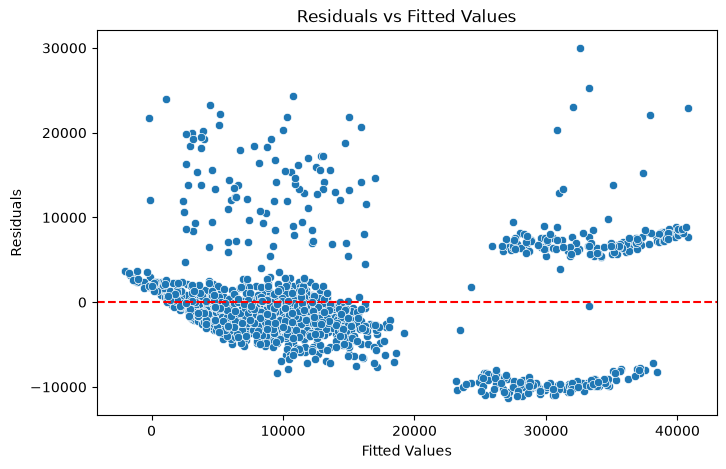

In [33]:
# Get fitted values and residuals

fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))

sns.scatterplot(x=fitted_values, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.show()

<Figure size 700x500 with 0 Axes>

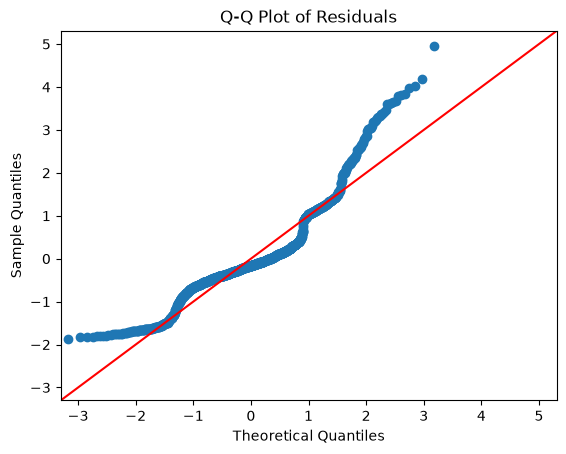

In [34]:
import statsmodels.api as sm

plt.figure(figsize=(7, 5))

sm.qqplot(residuals, line='45', fit=True)

plt.title('Q-Q Plot of Residuals')

plt.show()

In [35]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(residuals)

print("Jarque-Bera Test")
print("-----------------")
print("JB Statistic =", jb_stat)
print("p-value =", jb_pvalue)

Jarque-Bera Test
-----------------
JB Statistic = 718.8872635707942
p-value = 7.863468661808985e-157


In [36]:
from statsmodels.stats.stattools import omni_normtest

omnibus_stat, omnibus_pvalue = omni_normtest(residuals)

print("Omnibus Test")
print("------------")
print("Test Statistic =", omnibus_stat)
print("p-value =", omnibus_pvalue)

Omnibus Test
------------
Test Statistic = 300.36591553235706
p-value = 5.975443801306277e-66


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Continuous predictors only
continuous_vars = df_model[['age', 'bmi', 'children']]

vif_data = pd.DataFrame()

vif_data['Variable'] = continuous_vars.columns

vif_data['VIF'] = [
    variance_inflation_factor(
        continuous_vars.values,
        i
    )
    for i in range(continuous_vars.shape[1])
]

vif_data

,Variable,VIF
0,age,1.013816
1,bmi,1.012152
2,children,1.001874
